# 1 🎬 Sistema de Recomendação de Filmes com Análise Estatística

## 📌 Contexto

Este projeto tem como objetivo analisar padrões estatísticos em dados de filmes e desenvolver um sistema de recomendação baseado em similaridade.

Diferente de abordagens tradicionais, o modelo combina **similaridade de conteúdo** com **métricas de desempenho** (nota, popularidade e número de votos), proporcionando uma análise mais completa.

---

## ❓ Problema de Pesquisa

> Filmes com características semelhantes (gênero, elenco, palavras-chave) também apresentam padrões semelhantes de avaliação e popularidade?

---

## 🎯 Objetivo

Analisar a relação entre características dos filmes e seu desempenho utilizando técnicas estatísticas e vetores de similaridade.

### Objetivos Específicos

- Identificar padrões estatísticos em avaliações e popularidade  
- Agrupar filmes similares utilizando vetores  
- Comparar similaridade de conteúdo e desempenho  
- Avaliar se filmes recomendados possuem padrões semelhantes  

---

## 💡 Hipótese

> Filmes com características semelhantes tendem a apresentar padrões semelhantes de avaliação e popularidade.

# 2. Carregamento dos Dados

In [3]:
# Importando pacotes

import ast
import nltk
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
from nltk.stem import PorterStemmer, SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

pd.options.mode.chained_assignment = None


In [4]:

# ==========================================
# 📂 Carregamento dos Dados
# ==========================================

df_filmes = pd.read_csv("data/dataset_filmes.csv")
df_elenco = pd.read_csv("data/dataset_elenco.csv")

print("Dataset Filmes:", df_filmes.shape)
print("Dataset Elenco:", df_elenco.shape)




Dataset Filmes: (4803, 20)
Dataset Elenco: (4803, 4)


In [5]:
# ==========================================
# 🔗 Merge dos Dados
# ==========================================

df_completo = pd.merge(df_filmes, df_elenco, on='title')

print("\nDataset após merge:", df_completo.shape)





Dataset após merge: (4809, 23)


In [6]:
# ==========================================
# 🎯 Seleção de Features
# ==========================================

df_completo = df_completo[[
    "movie_id", "title", "genres", "keywords", "overview",
    "popularity", "runtime", "vote_average", "vote_count",
    "cast", "crew"
]]

# Visualização final inicial
df_completo.head(3)

,movie_id,title,genres,keywords,overview,popularity,runtime,vote_average,vote_count,cast,crew
0,19995,Avatar,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","In the 22nd century, a paraplegic Marine is di...",150.437577,162.0,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","Captain Barbossa, long believed to be dead, ha...",139.082615,169.0,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",A cryptic message from Bond’s past sends him o...,107.376788,148.0,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


# 3. Análise Exploratória de Dados (EDA)

In [8]:

# Verificando valores nulos e duplicados
print("Valores nulos por coluna:\n", df_completo.isnull().sum())
print("\nTotal de registros duplicados:", df_completo.duplicated().sum())


# ==========================================
# 🧹 Tratamento de Dados
# ==========================================

# Removendo valores nulos
df_completo.dropna(inplace=True)

print("\nDataset após remoção de nulos:")
df_completo.info()

print("\nObservação: Valores nulos serão removidos para garantir consistência na análise.")

Valores nulos por coluna:
 movie_id        0
title           0
genres          0
keywords        0
overview        3
popularity      0
runtime         2
vote_average    0
vote_count      0
cast            0
crew            0
dtype: int64

Total de registros duplicados: 0

Dataset após remoção de nulos:
<class 'pandas.core.frame.DataFrame'>
Index: 4806 entries, 0 to 4808
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   movie_id      4806 non-null   int64  
 1   title         4806 non-null   object 
 2   genres        4806 non-null   object 
 3   keywords      4806 non-null   object 
 4   overview      4806 non-null   object 
 5   popularity    4806 non-null   float64
 6   runtime       4806 non-null   float64
 7   vote_average  4806 non-null   float64
 8   vote_count    4806 non-null   int64  
 9   cast          4806 non-null   object 
 10  crew          4806 non-null   object 
dtypes: float64(3), int64(2), objec

# 4.  Processamento de Text

In [10]:


# Função para extrair nomes de listas JSON (genres, keywords)
def extract_names(obj):
    names = []
    for item in ast.literal_eval(obj):
        names.append(item['name'])
    return names


# Aplicando nas colunas
df_completo['genres'] = df_completo['genres'].apply(extract_names)
df_completo['keywords'] = df_completo['keywords'].apply(extract_names)


# ==========================================
# 🎭 Processamento de Elenco e Equipe
# ==========================================

# Função para extrair os 3 principais nomes (cast e crew)
def extract_top_names(obj, top_n=3):
    names = []
    for item in ast.literal_eval(obj):
        if len(names) == top_n:
            break
        names.append(item['name'])
    return names


# Aplicando transformação
df_completo['cast'] = df_completo['cast'].apply(extract_top_names)
df_completo['crew'] = df_completo['crew'].apply(extract_top_names)


# ==========================================
# 🧠 Feature Engineering
# ==========================================

# Criando coluna de conteúdo (para similaridade textual)
df_completo['Conteudo'] = (
    df_completo['genres'] +
    df_completo['cast'] +
    df_completo['crew'] +
    df_completo['keywords']
)

# Criando variável de performance (numérica)
df_completo['Performace'] = (
    df_completo['vote_average'] +
    df_completo['vote_count'] +
    df_completo['popularity']
)


# Visualização final da etapa
df_completo.head(3)

,movie_id,title,genres,keywords,overview,popularity,runtime,vote_average,vote_count,cast,crew,Conteudo,Performace
0,19995,Avatar,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","In the 22nd century, a paraplegic Marine is di...",150.437577,162.0,7.2,11800,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]","[Stephen E. Rivkin, Rick Carter, Christopher B...","[Action, Adventure, Fantasy, Science Fiction, ...",11957.637577
1,285,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","Captain Barbossa, long believed to be dead, ha...",139.082615,169.0,6.9,4500,"[Johnny Depp, Orlando Bloom, Keira Knightley]","[Dariusz Wolski, Gore Verbinski, Jerry Bruckhe...","[Adventure, Fantasy, Action, Johnny Depp, Orla...",4645.982615
2,206647,Spectre,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...",A cryptic message from Bond’s past sends him o...,107.376788,148.0,6.3,4466,"[Daniel Craig, Christoph Waltz, Léa Seydoux]","[Thomas Newman, Sam Mendes, Anna Pinnock]","[Action, Adventure, Crime, Daniel Craig, Chris...",4579.676788


# 5.  Parse e Vetorização

In [12]:
# ==========================================
# 🔤 Processamento de Texto (Stemming)
# ==========================================

stemmer = PorterStemmer()

def apply_stemming(text):
    tokens = text.split()
    stemmed_tokens = [stemmer.stem(word) for word in tokens]
    return " ".join(stemmed_tokens)


# Aplicando no overview
df_completo['overview'] = df_completo['overview'].apply(apply_stemming)


# ==========================================
# 🧹 Limpeza de Texto
# ==========================================

# Função para padronizar listas de texto
def clean_text_list(text_list):
    return [item.lower().replace(" ", "") for item in text_list]


cols_to_clean = ['genres', 'keywords', 'cast', 'crew']

for col in cols_to_clean:
    df_completo[col] = df_completo[col].apply(clean_text_list)


# Atualizando Conteúdo após limpeza
df_completo['Conteudo'] = (
    df_completo['genres'] +
    df_completo['cast'] +
    df_completo['crew'] +
    df_completo['keywords']
)


# Convertendo lista para string (necessário para vetorização)
df_completo['Conteudo_str'] = df_completo['Conteudo'].apply(lambda x: " ".join(x))


# ==========================================
# 🧠 Vetorização
# ==========================================

# Vetorização do conteúdo textual
vectorizer = CountVectorizer(max_features=5000, stop_words="english")
vectors_conteudo = vectorizer.fit_transform(df_completo['Conteudo_str']).toarray()


# ==========================================
# 📊 Normalização de Features Numéricas
# ==========================================

scaler = StandardScaler()

vectors_performance = scaler.fit_transform(
    df_completo[["vote_average", "vote_count", "popularity"]]
)


# ==========================================
# 🔗 Combinação (Modelo Híbrido)
# ==========================================

vectors_hibrido = np.hstack([vectors_conteudo, vectors_performance])

print("Shape final do modelo híbrido:", vectors_hibrido.shape)

Shape final do modelo híbrido: (4806, 5003)


# 6.  Cálculo de Similaridade

In [14]:

# Similaridade baseada em conteúdo textual
sim_conteudo = cosine_similarity(vectors_conteudo)

# Similaridade baseada em métricas de performance
sim_performance = cosine_similarity(vectors_performance)


# ==========================================
# ⚖️ Combinação Híbrida
# ==========================================

# Pesos definidos empiricamente
alpha = 0.7  # peso do conteúdo
beta = 0.3   # peso da performance

sim_final = (alpha * sim_conteudo) + (beta * sim_performance)




# 7. 🎬 Sistema de Recomendação

In [16]:

def sistema_recomendacao(movie, top_n=5):
    """
    Retorna recomendações de filmes com base em similaridade híbrida.

    Parâmetros:
    - movie (str): nome do filme
    - top_n (int): quantidade de recomendações

    Retorno:
    - list: lista com títulos recomendados
    """

    # Verifica se o filme existe
    if movie not in df_completo['title'].values:
        return f"Filme '{movie}' não encontrado."

    # Obtém índice do filme
    idx = df_completo[df_completo['title'] == movie].index[0]

    # Calcula similaridade
    similaridades = list(enumerate(sim_final[idx]))

    # Ordena do mais similar para o menos similar
    similaridades = sorted(similaridades, key=lambda x: x[1], reverse=True)

    # Ignora o próprio filme e pega os top N
    top_filmes = similaridades[1:top_n + 1]

    # Retorna apenas os títulos
    recomendacoes = [df_completo.iloc[i[0]].title for i in top_filmes]

    return recomendacoes

# 8. Aplicando Sistema Recomendação

In [18]:

# Testes do Sistema de Recomendação


filmes_teste = [
    "Avengers: Age of Ultron",
    "Jurassic World",
    "The Hobbit: The Battle of the Five Armies"
]

for filme in filmes_teste:
    print(f"\n🎬 Filme base: {filme}")
    recomendacoes = sistema_recomendacao(filme)
    
    for i, rec in enumerate(recomendacoes, 1):
        print(f"{i}. {rec}")


🎬 Filme base: Avengers: Age of Ultron
1. The Avengers
2. Ant-Man
3. Captain America: Civil War
4. Thor: The Dark World
5. Guardians of the Galaxy

🎬 Filme base: Jurassic World
1. Jurassic Park
2. Terminator Genisys
3. Journey to the Center of the Earth
4. Transformers: Age of Extinction
5. Dawn of the Planet of the Apes

🎬 Filme base: The Hobbit: The Battle of the Five Armies
1. The Hobbit: The Desolation of Smaug
2. The Hobbit: An Unexpected Journey
3. The Lord of the Rings: The Fellowship of the Ring
4. The Lord of the Rings: The Two Towers
5. The Lord of the Rings: The Return of the King


# Análise Estatística

Dataset preparado para análise estatística:


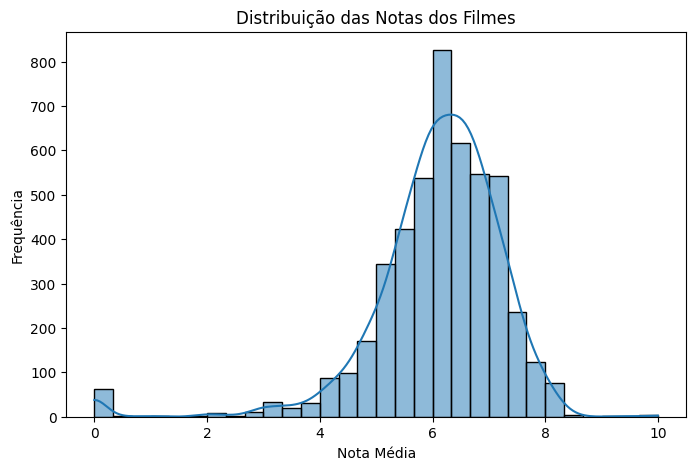

Estatísticas descritivas:
         vote_average   vote_count  popularity
mean        6.093258   690.758427   21.504750
median      6.200000   236.000000   12.928897
std         1.190846  1234.454061   31.808977

Correlação Nota vs Popularidade: 0.27
Correlação Nota vs Votos: 0.31

Média por gênero:
              vote_average   vote_count  popularity
genres                                            
history          6.719797   486.791878   17.444839
war              6.713889   756.645833   23.777289
drama            6.388169   532.061331   17.761710
music            6.355676   300.497297   13.101512
foreign          6.352941    10.764706    0.686787
animation        6.341453  1246.170940   38.813439
documentary      6.285185    71.824074    4.010956
crime            6.273888   751.810617   22.834569
romance          6.207486   456.026816   15.992561
mystery          6.183908   799.146552   24.586827


In [20]:

# Removendo colunas auxiliares
df_completo = df_completo.drop(['Conteudo', 'Performace', 'Conteudo_str'], axis=1)

print("Dataset preparado para análise estatística:")
df_completo.head(2)


# ==========================================
# 📈 Distribuição das Notas
# ==========================================

plt.figure(figsize=(8,5))
sns.histplot(df_completo['vote_average'], bins=30, kde=True)
plt.title("Distribuição das Notas dos Filmes")
plt.xlabel("Nota Média")
plt.ylabel("Frequência")
plt.show()


# ==========================================
# 📊 Estatísticas Descritivas
# ==========================================

stats = df_completo[['vote_average', 'vote_count', 'popularity']].agg(['mean','median','std'])
print("Estatísticas descritivas:\n", stats)


# ==========================================
# 🔗 Análise de Correlação
# ==========================================

corr_nota_pop = df_completo['vote_average'].corr(df_completo['popularity'])
corr_voto_nota = df_completo['vote_average'].corr(df_completo['vote_count'])

print(f"\nCorrelação Nota vs Popularidade: {corr_nota_pop:.2f}")
print(f"Correlação Nota vs Votos: {corr_voto_nota:.2f}")


# ==========================================
# 🎭 Análise por Gênero
# ==========================================

df_exploded = df_completo.explode('genres')

genero_stats = (
    df_exploded
    .groupby('genres')[['vote_average', 'vote_count', 'popularity']]
    .mean()
    .sort_values(by='vote_average', ascending=False)
)

print("\nMédia por gênero:\n", genero_stats.head(10))


**Insights:**

- A correlação entre nota e popularidade é fraca (≈0.27), indicando que filmes populares
  não necessariamente são melhor avaliados.

- A correlação entre número de votos e nota também é baixa (≈0.31), sugerindo que maior
  engajamento não garante melhor avaliação.

- Alguns gêneros apresentam médias de avaliação superiores, indicando possíveis padrões
  de preferência do público.



A partir das análises iniciais, surgem algumas questões importantes:

1. Filmes similares possuem avaliações semelhantes?
2. A popularidade influencia a avaliação?
3. Existe um padrão entre gêneros?

Essas perguntas serão exploradas a seguir com o apoio de visualizações.


## ❓ Pergunta 1: Filmes similares têm notas parecidas?

🎬 Filme base: The Hobbit: The Battle of the Five Armies

Recomendações: ['The Hobbit: The Desolation of Smaug', 'The Hobbit: An Unexpected Journey', 'The Lord of the Rings: The Fellowship of the Ring', 'The Lord of the Rings: The Two Towers', 'The Lord of the Rings: The Return of the King']


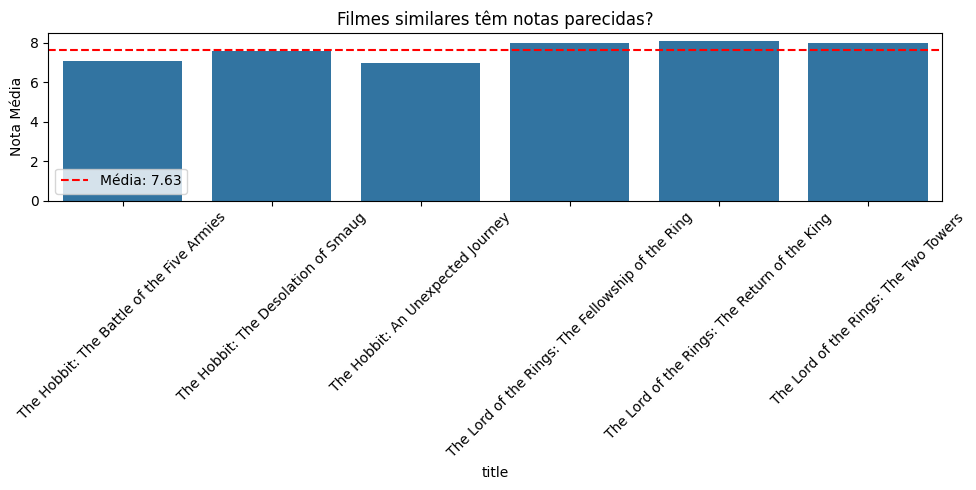

In [24]:


movie = "The Hobbit: The Battle of the Five Armies"

# Obtendo recomendações
recomendacoes = sistema_recomendacao(movie)

# Criando dataset para análise
data = df_completo[
    df_completo['title'].isin([movie] + recomendacoes)
][['title', 'vote_average']]

media = data['vote_average'].mean()

print(f"🎬 Filme base: {movie}")
print("\nRecomendações:", recomendacoes)


# ==========================================
# 📊 Visualização
# ==========================================

plt.figure(figsize=(10,5))

sns.barplot(data=data, x='title', y='vote_average')

plt.xticks(rotation=45)
plt.title("Filmes similares têm notas parecidas?")
plt.ylabel("Nota Média")

# Linha da média
plt.axhline(media, color="red", linestyle="--", label=f"Média: {media:.2f}")

plt.legend()
plt.tight_layout()
plt.show()


**Insight:**

Os filmes recomendados apresentam notas relativamente próximas entre si,
com média consistente, indicando que o sistema de recomendação consegue
agrupar filmes com padrões semelhantes de avaliação.

Isso sugere que a similaridade baseada em conteúdo e performance é eficaz
na identificação de filmes com recepção similar pelo público.


## ❓ Pergunta 2: Popularidade Influencia Avaliação ?

Correlação Nota x Popularidade: 0.27
Correlação Nota x Votos: 0.31


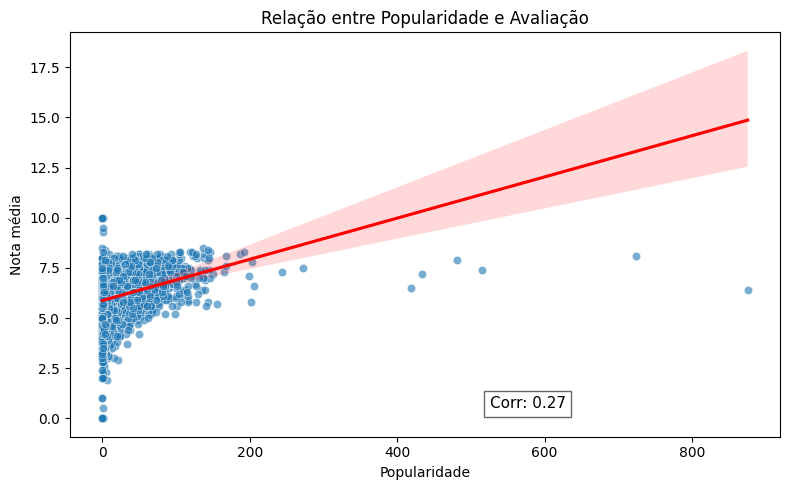

In [27]:
# ==========================================
# Correlações
# ==========================================

corr_NotaPop = df_completo['vote_average'].corr(df_completo['popularity'])
corr_VotoNota = df_completo['vote_average'].corr(df_completo['vote_count'])

print(f"Correlação Nota x Popularidade: {corr_NotaPop:.2f}")
print(f"Correlação Nota x Votos: {corr_VotoNota:.2f}")


# ==========================================
# Gráfico
# ==========================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_completo,
    x='popularity',
    y='vote_average',
    alpha=0.6
)

# Linha de tendência
sns.regplot(
    data=df_completo,
    x='popularity',
    y='vote_average',
    scatter=False,
    color='red'
)

#  Mostrar correlação DENTRO do gráfico
plt.text(
    x=df_completo['popularity'].max()*0.6,
    y=df_completo['vote_average'].min()+0.5,
    s=f"Corr: {corr_NotaPop:.2f}",
    fontsize=11,
    bbox=dict(facecolor='white', alpha=0.6)
)

plt.xlabel("Popularidade")
plt.ylabel("Nota média")
plt.title("Relação entre Popularidade e Avaliação")

plt.tight_layout()
plt.show()


Insight:

Apesar da correlação positiva, ela é fraca, indicando que popularidade
não garante qualidade.

Isso pode ocorrer porque:
- Filmes muito populares podem ser impulsionados por marketing
- Filmes nichados podem ter alta avaliação, mas baixa popularidade

Portanto, popularidade e avaliação capturam dimensões diferentes do sucesso de um filme.


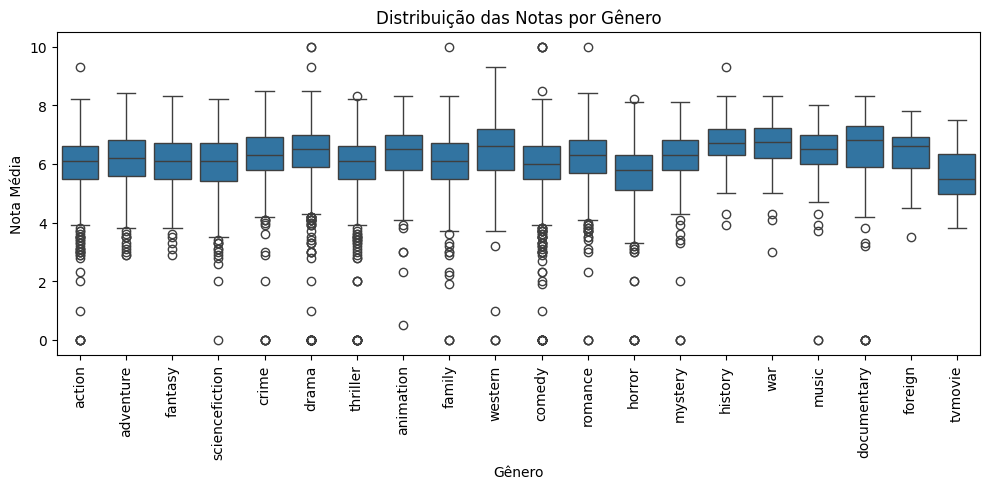

In [38]:
# Corrigir índice duplicado
df_exploded = df_exploded.reset_index(drop=True)

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df_exploded,
    x='genres',
    y='vote_average'
)

plt.xticks(rotation=90)
plt.title("Distribuição das Notas por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Nota Média")

plt.tight_layout()

plt.show()


**Insight:**

Observa-se que alguns gêneros apresentam distribuições de notas mais altas,
indicando uma tendência de melhor avaliação média pelo público.

Além disso, a dispersão varia entre gêneros, sugerindo que certos tipos de filme
são mais consistentes em qualidade, enquanto outros apresentam maior variabilidade.

Isso indica que o gênero é um fator relevante na percepção de qualidade dos filmes.
